In [1]:
import sys
from pathlib import Path

# The notebook runs from notebooks/, so put the project root on the import path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.config import settings

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.3f}".format)


In [2]:
df = pd.read_csv(settings.raw_data_path)
print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.000,-1.360,-0.073,2.536,1.378,-0.338,0.462,0.240,0.099,0.364,0.091,-0.552,-0.618,-0.991,-0.311,1.468,-0.470,0.208,0.026,0.404,0.251,-0.018,0.278,-0.110,0.067,0.129,-0.189,0.134,-0.021,149.620,0
1,0.000,1.192,0.266,0.166,0.448,0.060,-0.082,-0.079,0.085,-0.255,-0.167,1.613,1.065,0.489,-0.144,0.636,0.464,-0.115,-0.183,-0.146,-0.069,-0.226,-0.639,0.101,-0.340,0.167,0.126,-0.009,0.015,2.690,0
2,1.000,-1.358,-1.340,1.773,0.380,-0.503,1.800,0.791,0.248,-1.515,0.208,0.625,0.066,0.717,-0.166,2.346,-2.890,1.110,-0.121,-2.262,0.525,0.248,0.772,0.909,-0.689,-0.328,-0.139,-0.055,-0.060,378.660,0
3,1.000,-0.966,-0.185,1.793,-0.863,-0.010,1.247,0.238,0.377,-1.387,-0.055,-0.226,0.178,0.508,-0.288,-0.631,-1.060,-0.684,1.966,-1.233,-0.208,-0.108,0.005,-0.190,-1.176,0.647,-0.222,0.063,0.061,123.500,0
4,2.000,-1.158,0.878,1.549,0.403,-0.407,0.096,0.593,-0.271,0.818,0.753,-0.823,0.538,1.346,-1.120,0.175,-0.451,-0.237,-0.038,0.803,0.409,-0.009,0.798,-0.137,0.141,-0.206,0.502,0.219,0.215,69.990,0


In [3]:
df.info()
print("missing values:", df.isna().sum().sum())
df[["Time", "Amount", "V1", "V14", "Class"]].describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

,Time,Amount,V1,V14,Class
count,284807.000,284807.000,284807.000,284807.000,284807.000
mean,94813.860,88.350,0.000,0.000,0.002
std,47488.146,250.120,1.959,0.959,0.042
min,0.000,0.000,-56.408,-19.214,0.000
25%,54201.500,5.600,-0.920,-0.426,0.000
50%,84692.000,22.000,0.018,0.051,0.000
75%,139320.500,77.165,1.316,0.493,0.000
max,172792.000,25691.160,2.455,10.527,1.000


In [4]:
dupes = df.duplicated()
print(f"duplicate rows:   {dupes.sum()}")
print(f"  of which fraud: {df.loc[dupes, 'Class'].sum()}")
print(f"fraud after dedup: {df.drop_duplicates()['Class'].sum()} "
      f"of {len(df.drop_duplicates())} rows")


duplicate rows:   1081
  of which fraud: 19
fraud after dedup: 473 of 283726 rows


Class
0    284315
1       492
Name: count, dtype: int64
fraud rate: 0.1727%  ->  1 fraud per 578 transactions


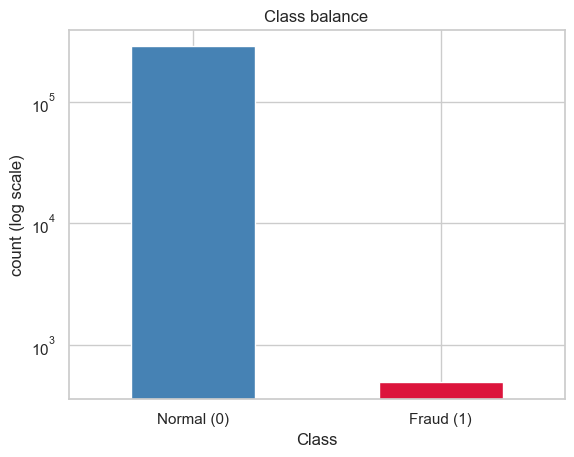

In [5]:
counts = df["Class"].value_counts()
rate = counts[1] / len(df)
print(counts)
print(f"fraud rate: {rate:.4%}  ->  1 fraud per {int(1 / rate)} transactions")

ax = counts.plot.bar(logy=True, color=["steelblue", "crimson"])
ax.set_xticklabels(["Normal (0)", "Fraud (1)"], rotation=0)
ax.set_ylabel("count (log scale)")
ax.set_title("Class balance")
plt.show()


In [6]:
from sklearn.metrics import accuracy_score, recall_score

always_normal = np.zeros(len(df), dtype=int)
print(f"accuracy: {accuracy_score(df['Class'], always_normal):.4%}")
print(f"recall:   {recall_score(df['Class'], always_normal):.4%}")


accuracy: 99.8273%
recall:   0.0000%


           count    mean     std   min   25%    50%     75%       max
Class                                                                
0     284315.000  88.291 250.105 0.000 5.650 22.000  77.050 25691.160
1        492.000 122.211 256.683 0.000 1.000  9.250 105.890  2125.870

zero-amount transactions: {0: 1798, 1: 27}


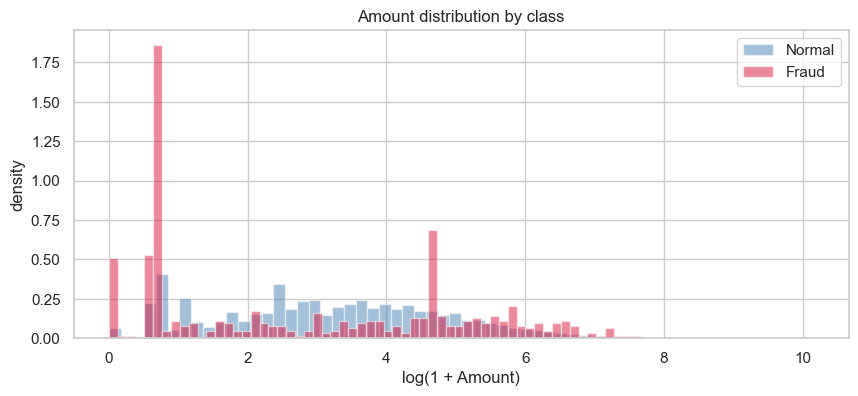

In [7]:
print(df.groupby("Class")["Amount"].describe())
print("\nzero-amount transactions:", df[df["Amount"] == 0]["Class"].value_counts().to_dict())

fig, ax = plt.subplots(figsize=(10, 4))
for label, color in [(0, "steelblue"), (1, "crimson")]:
    subset = df.loc[df["Class"] == label, "Amount"]
    ax.hist(np.log1p(subset), bins=60, density=True, alpha=0.5, color=color,
            label="Fraud" if label else "Normal")
ax.set_xlabel("log(1 + Amount)")
ax.set_ylabel("density")
ax.set_title("Amount distribution by class")
ax.legend()
plt.show()


data spans 48.0 hours


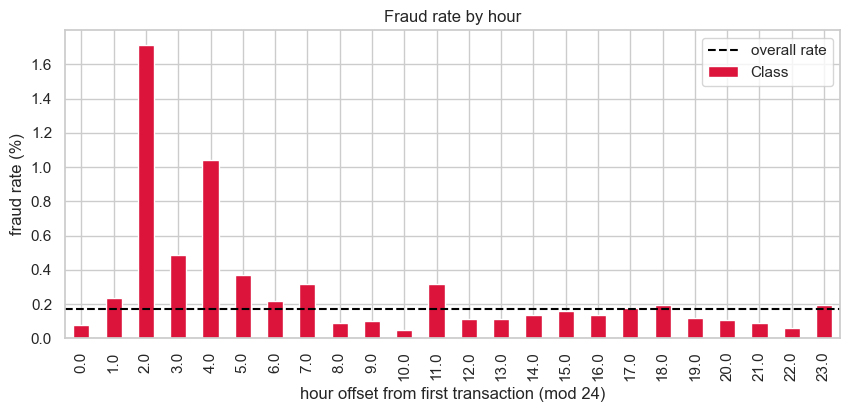

In [8]:
df["hour"] = (df["Time"] // 3600) % 24
print(f"data spans {df['Time'].max() / 3600:.1f} hours")

fraud_rate_by_hour = df.groupby("hour")["Class"].mean() * 100
ax = fraud_rate_by_hour.plot.bar(figsize=(10, 4), color="crimson")
ax.axhline(df["Class"].mean() * 100, ls="--", color="black", label="overall rate")
ax.set_xlabel("hour offset from first transaction (mod 24)")
ax.set_ylabel("fraud rate (%)")
ax.set_title("Fraud rate by hour")
ax.legend()
plt.show()


In [9]:
v_cols = [f"V{i}" for i in range(1, 29)]

class_means = df.groupby("Class")[v_cols].mean().T
class_means.columns = ["normal_mean", "fraud_mean"]
class_means["gap"] = (class_means["fraud_mean"] - class_means["normal_mean"]).abs()
class_means = class_means.sort_values("gap", ascending=False)
class_means.head(10)


,normal_mean,fraud_mean,gap
V3,0.012,-7.033,7.045
V14,0.012,-6.972,6.984
V17,0.012,-6.666,6.677
V12,0.011,-6.259,6.270
V10,0.010,-5.677,5.687
V7,0.010,-5.569,5.578
V1,0.008,-4.772,4.780
V4,-0.008,4.542,4.550
V16,0.007,-4.140,4.147
V11,-0.007,3.800,3.807


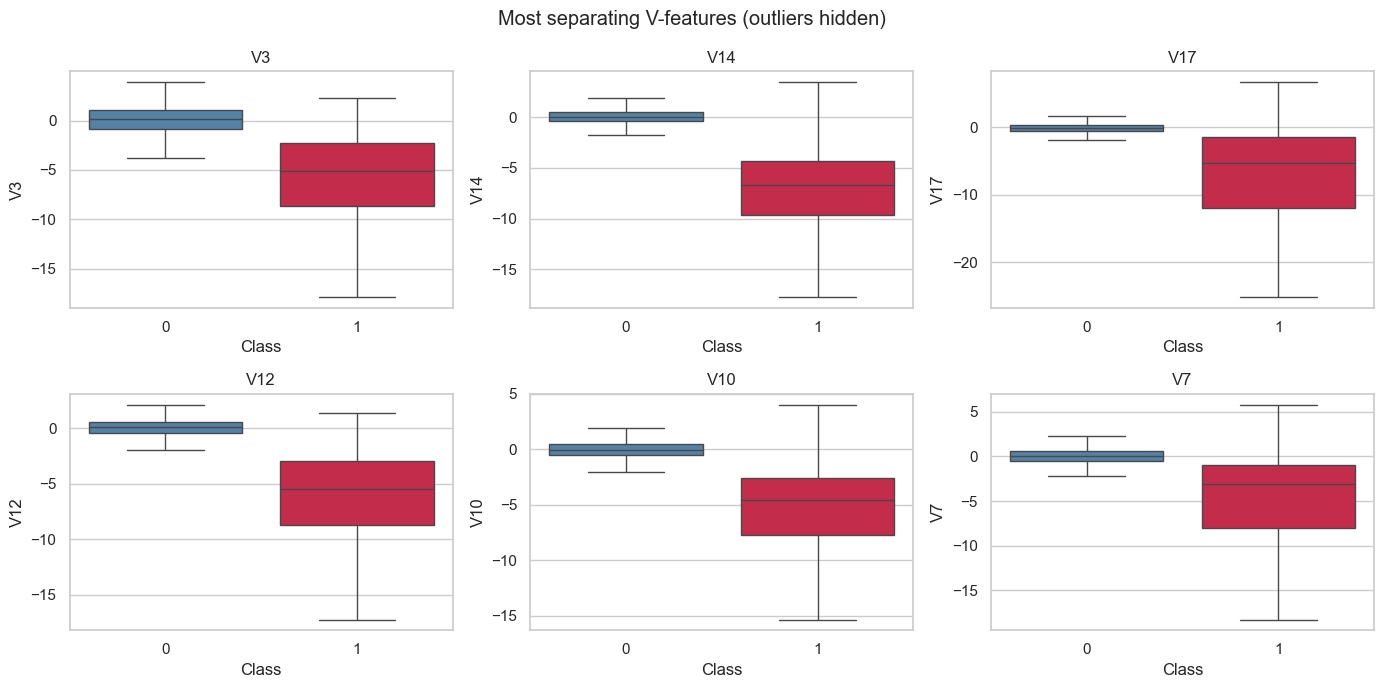

In [10]:
top = class_means.index[:6]

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, top):
    sns.boxplot(data=df, x="Class", y=col, ax=ax, showfliers=False,
                hue="Class", palette={0: "steelblue", 1: "crimson"}, legend=False)
    ax.set_title(col)
fig.suptitle("Most separating V-features (outliers hidden)")
plt.tight_layout()
plt.show()


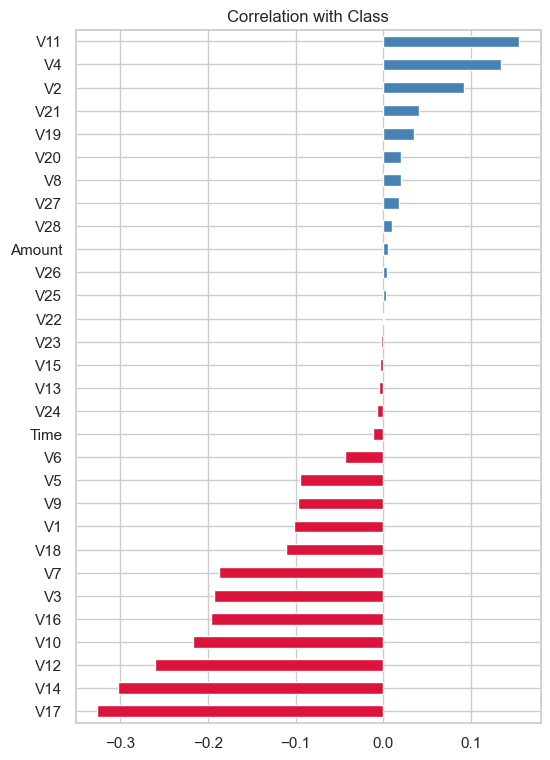

In [11]:
corr = df[v_cols + ["Amount", "Time", "Class"]].corr()["Class"].drop("Class").sort_values()

ax = corr.plot.barh(figsize=(6, 9), color=list(np.where(corr < 0, "crimson", "steelblue")))
ax.set_title("Correlation with Class")
plt.show()


## Findings -> decisions for Step 1.2

1. **Heavy imbalance: 0.173% fraud.** Accuracy is meaningless (predicting all-normal scores 99.83%).
   -> Evaluate with PR-AUC, precision and recall. Use a *stratified* split.
2. **1,081 duplicate rows (19 fraud).** Twins split across train and test would leak.
   -> Drop duplicates *before* splitting. 473 fraud cases remain.
3. **No missing values.** No imputation needed.
4. **Amount and Time are on raw scales; V1–V28 are already centered.**
   -> Scale Amount and Time only.
5. **Fraud separates strongly on V14, V17, V12, V10, V3**, several standard deviations from normal.
   -> An anomaly detector has a real signal to find.
6. **Fraud rate spikes about 10x at hour-offset 2.** Worth noting; can't use it properly
   without real clock time.
